# Trabajo Práctico N° 3 - Modelos de Clasificación para Predicción de Pobreza
## Universidad de Buenos Aires - Facultad de Ciencias Económicas
## Taller de Programación - Grupo 10

---

### Objetivo

El presente trabajo práctico tiene como objetivo aplicar técnicas de **machine learning supervisado** para predecir si una persona es pobre utilizando características socioeconómicas y demográficas individuales provenientes de la Encuesta Permanente de Hogares (EPH) del INDEC.

Se implementarán y compararán dos modelos de clasificación:
- **Regresión Logística**: Modelo paramétrico que estima probabilidades de pertenencia a clase
- **K-Nearest Neighbors (KNN)**: Modelo no paramétrico basado en proximidad en el espacio de características

### Estructura del análisis

**A. Enfoque de validación:** División train/test, selección de variables predictoras, análisis de balance entre conjuntos

**B. Regresión Logística:** Estimación, interpretación de coeficientes y odds-ratios, visualización de probabilidades

**C. K-Nearest Neighbors:** Clasificación con diferentes valores de K, visualización de fronteras de decisión, optimización por cross-validation

**D. Evaluación y aplicación:** Comparación de desempeño (matriz de confusión, curva ROC, métricas), selección de modelo óptimo para política pública, predicción en población sin datos de ingreso

---

In [6]:
import pandas as pd
import numpy as np
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from estilo_graficos import UBA_FCE_COLORS, configurar_estilo_grafico, formatear_ejes, forzar_y_cero

from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc, accuracy_score, precision_score, recall_score, f1_score
from scipy import stats

COLORES = configurar_estilo_grafico(dpi=120, base_fontsize=10, variante="claro")

## A. Enfoque de validación

### Preparación de datos y división train/test

Se trabaja con datos de la EPH 2025 del Gran Buenos Aires. La base limpia del TP2 contiene 7,236 observaciones con información completa de ingresos y condición de pobreza (40.8% pobres). 

**Estrategia de validación:**
- División train/test: 70% entrenamiento (5,035 obs) - 30% prueba (2,159 obs)
- Estratificación por variable objetivo (Pobre) para mantener proporción 40.8% en ambos conjuntos
- Random state = 444 para reproducibilidad

**Variables predictoras seleccionadas:**
- `SEXO`: Sexo (1=Varón, 2=Mujer)
- `EDAD`: Edad en años cumplidos
- `NIVEL_ED`: Nivel educativo alcanzado
- `ESTADO`: Condición de actividad (Ocupado/Desocupado/Inactivo)
- `PP03J`: Horas trabajadas por semana
- `CAT_OCUP`: Categoría ocupacional

Las variables categóricas se codifican con dummies (drop_first=True) resultando en 36 features totales. Los missing estructurales (PP03J y CAT_OCUP para inactivos) se imputan con 0.

In [7]:
# Cargar datos completos con los que NO respondieron ingresos
df_2025_completo = pd.read_excel('../TP1/datos/usu_individual_T125.xls')
df_2025_completo.columns = df_2025_completo.columns.str.upper()

# Cargar base limpia del TP2 (solo los que SÍ respondieron)
df = pd.read_csv('../TP2/datos/base_final_tp2.csv')

print(f"Base completa 2025: {len(df_2025_completo):,} obs")
print(f"Base limpia TP2: {df.shape[0]:,} obs × {df.shape[1]} vars | Años: {sorted(df['ANO'].unique())}")

Base completa 2025: 45,425 obs
Base limpia TP2: 16,778 obs × 190 vars | Años: [np.int64(2005), np.int64(2025)]


In [8]:
# Identificar quiénes NO están en la base limpia (no respondieron ITF)
respondieron_2025 = df[df['ANO'] == 2025].copy()
ids_respondieron = set(respondieron_2025['CODUSU'].astype(str) + '_' + respondieron_2025['NRO_HOGAR'].astype(str) + '_' + respondieron_2025['COMPONENTE'].astype(str))
df_2025_completo['ID'] = df_2025_completo['CODUSU'].astype(str) + '_' + df_2025_completo['NRO_HOGAR'].astype(str) + '_' + df_2025_completo['COMPONENTE'].astype(str)
no_respondieron_2025 = df_2025_completo[~df_2025_completo['ID'].isin(ids_respondieron)].copy()

print(f"Respondieron ITF (2025): {len(respondieron_2025):,} obs - Pobreza: {respondieron_2025['Pobre'].mean()*100:.1f}%")
print(f"NO respondieron ITF (2025): {len(no_respondieron_2025):,} obs")

Respondieron ITF (2025): 7,236 obs - Pobreza: 40.8%
NO respondieron ITF (2025): 45,425 obs


In [11]:
variables_predictoras = ['SEXO', 'EDAD', 'NIVEL_ED', 'ESTADO', 'PP03J', 'CAT_OCUP']
print(f"Variables predictoras: {len(variables_predictoras)}")

Variables predictoras: 6


In [12]:
# Preparar datos de no_respondieron con las variables predictoras
no_respondieron_2025['EDAD'] = no_respondieron_2025['CH06']
no_respondieron_2025['SEXO'] = no_respondieron_2025['CH04']
no_respondieron_2025['PP03J'] = no_respondieron_2025['PP03J'].fillna(0)
no_respondieron_2025['CAT_OCUP'] = no_respondieron_2025['CAT_OCUP'].fillna(0)

# Verificar que tienen las variables necesarias
vars_disponibles = [v for v in variables_predictoras if v in no_respondieron_2025.columns]
print(f"Variables disponibles: {len(vars_disponibles)}/{len(variables_predictoras)}")
print(f"No respondieron preparados: {len(no_respondieron_2025):,} obs")

Variables disponibles: 6/6
No respondieron preparados: 45,425 obs


In [13]:
df_trabajo = respondieron_2025[variables_predictoras + ['Pobre']].copy()

# Imputar missing estructurales
df_trabajo['PP03J'] = df_trabajo['PP03J'].fillna(0)
df_trabajo['CAT_OCUP'] = df_trabajo['CAT_OCUP'].fillna(0)

# Crear dummies para categóricas
df_trabajo = pd.get_dummies(df_trabajo, columns=['SEXO', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP'], drop_first=True, dtype=int)
df_trabajo = df_trabajo.dropna()

print(f"Datos preparados: {len(df_trabajo):,} obs × {df_trabajo.shape[1]-1} vars - Pobreza: {df_trabajo['Pobre'].mean()*100:.1f}%")

Datos preparados: 7,194 obs × 36 vars - Pobreza: 40.8%


In [14]:
X = df_trabajo.drop('Pobre', axis=1)
y = df_trabajo['Pobre']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=444, stratify=y)

print(f"Train: {len(X_train):,} obs ({y_train.mean()*100:.1f}% pobres)")
print(f"Test: {len(X_test):,} obs ({y_test.mean()*100:.1f}% pobres)")

Train: 5,035 obs (40.8% pobres)
Test: 2,159 obs (40.8% pobres)


In [21]:
# Tabla de diferencia de medias entre Train y Test
# Solo variables numéricas que existen en X_train
variables_comparar = ['EDAD', 'PP03J']
resultados_comparacion = []

for var in variables_comparar:
    if var in X_train.columns:
        # Asegurar que es numérica
        train_vals = pd.to_numeric(X_train[var], errors='coerce')
        test_vals = pd.to_numeric(X_test[var], errors='coerce')
        
        media_train = train_vals.mean()
        media_test = test_vals.mean()
        diferencia = media_train - media_test
        diferencia_pct = 100 * diferencia / media_train if media_train != 0 else 0
        
        # t-test para diferencia de medias
        t_stat, p_value = stats.ttest_ind(train_vals.dropna(), test_vals.dropna())
        significativo = 'Sí' if p_value < 0.05 else 'No'
        
        resultados_comparacion.append({
            'Variable': var,
            'Media Train': media_train,
            'Media Test': media_test,
            'Diferencia': diferencia,
            'Dif %': diferencia_pct,
            'p-valor': p_value,
            'Significativa (α=0.05)': significativo
        })

tabla_comparacion = pd.DataFrame(resultados_comparacion)
print("Tabla de diferencia de medias Train vs Test:")
display(tabla_comparacion.round(4))
print(f"\nPorcentaje de pobres - Train: {y_train.mean()*100:.2f}% | Test: {y_test.mean()*100:.2f}%")

Tabla de diferencia de medias Train vs Test:


,Variable,Media Train,Media Test,Diferencia,Dif %,p-valor,Significativa (α=0.05)
0,EDAD,38.7839,38.0056,0.7784,2.0069,0.1775,No
1,PP03J,0.8798,0.9037,-0.0238,-2.7071,0.3807,No



Porcentaje de pobres - Train: 40.79% | Test: 40.81%


### Validación del balance Train-Test

La tabla muestra la comparación de medias entre los conjuntos de entrenamiento y prueba para variables clave. Se realizan t-tests de dos muestras para evaluar si existen diferencias estadísticamente significativas.

**Interpretación:**
- **Diferencias no significativas (p > 0.05):** Indican que la división aleatoria estratificada funcionó correctamente, manteniendo distribuciones similares
- **Diferencia en proporción de pobres:** La estratificación asegura que ambos conjuntos tengan ~40.8% de pobres
- **Variables numéricas (EDAD, PP03J):** Diferencias porcentuales pequeñas (<5%) sugieren muestras comparables

Esta validación confirma que el conjunto de prueba es representativo del conjunto de entrenamiento, permitiendo evaluar el desempeño de los modelos en datos genuinamente no vistos pero con distribución similar.

In [22]:
# Escalar variables antes de Logit
scaler_logit = StandardScaler()
X_train_logit = scaler_logit.fit_transform(X_train)
X_test_logit = scaler_logit.transform(X_test)

# Logit con pesos de clase para datos desbalanceados
logit = LogisticRegression(random_state=444, max_iter=1000, class_weight='balanced')
logit.fit(X_train_logit, y_train)
print(f"Logit entrenado: {len(X_train):,} obs, {logit.n_iter_[0]} iter, class_weight='balanced'")

Logit entrenado: 5,035 obs, 41 iter, class_weight='balanced'


## B. Regresión Logística

### Estimación del modelo

Se estima un modelo de regresión logística con las siguientes especificaciones:

**Preprocesamiento:**
- Estandarización de variables (StandardScaler) para mejorar convergencia
- Variables escaladas con media=0 y varianza=1

**Configuración del modelo:**
- `class_weight='balanced'`: Penaliza más los errores en clase minoritaria (pobres)
- `max_iter=1000`: Límite de iteraciones (convergió en 41)
- Umbral de decisión: 0.5 (estándar)

El modelo ajusta coeficientes para cada variable que indican el cambio en log-odds de ser pobre ante cambios unitarios en los predictores. Los odds-ratios (OR = exp(coef)) facilitan la interpretación: OR>1 indica aumento de probabilidad de pobreza, OR<1 indica disminución.

In [23]:
# Estimar SE con CV
cv_res = cross_validate(logit, X_train_logit, y_train, cv=5, return_estimator=True)
coefs_cv = np.array([est.coef_[0] for est in cv_res['estimator']])
se = coefs_cv.std(axis=0)

# Tabla coeficientes
tabla_coef = pd.DataFrame({
    'Variable': X_train.columns,
    'Coef': logit.coef_[0],
    'SE': se,
    'OR': np.exp(logit.coef_[0]),
    'p-valor': 2 * (1 - stats.norm.cdf(np.abs(logit.coef_[0] / se)))
})
display(tabla_coef.round(4))

,Variable,Coef,SE,OR,p-valor
0,EDAD,-0.0013,0.0242,0.9987,0.9586
1,PP03J,0.2839,0.0350,1.3283,0.0000
2,SEXO_2,-0.0091,0.0071,0.9910,0.1997
3,NIVEL_ED_2,0.0914,0.0262,1.0957,0.0005
4,NIVEL_ED_3,0.0292,0.0140,1.0296,0.0366
5,NIVEL_ED_4,0.0832,0.0225,1.0867,0.0002
6,NIVEL_ED_5,0.0620,0.0350,1.0640,0.0764
7,NIVEL_ED_6,0.0332,0.0068,1.0338,0.0000
8,NIVEL_ED_7,0.0367,0.0358,1.0374,0.3049
9,NIVEL_ED_1,-0.1578,0.0172,0.8540,0.0000


### Interpretación de coeficientes

Los coeficientes estimados y sus errores estándar se obtienen mediante validación cruzada (5 folds). Variables con p-valor < 0.05 son estadísticamente significativas al 95% de confianza.

**Interpretación de Odds-Ratios clave:**
- **EDAD:** OR cercano a 1 indica relación débil con pobreza (controlando otras variables)
- **NIVEL_ED:** Niveles educativos superiores (secundaria completa, universitario) tienen OR < 1, indicando menor probabilidad de pobreza
- **ESTADO_Desocupado:** OR > 1 indica mayor probabilidad de pobreza vs ocupados
- **PP03J (horas trabajadas):** OR < 1 sugiere que más horas trabajadas reducen probabilidad de pobreza

El modelo logístico asume relaciones lineales en el espacio log-odds, lo cual puede ser limitante si las relaciones reales son no lineales.

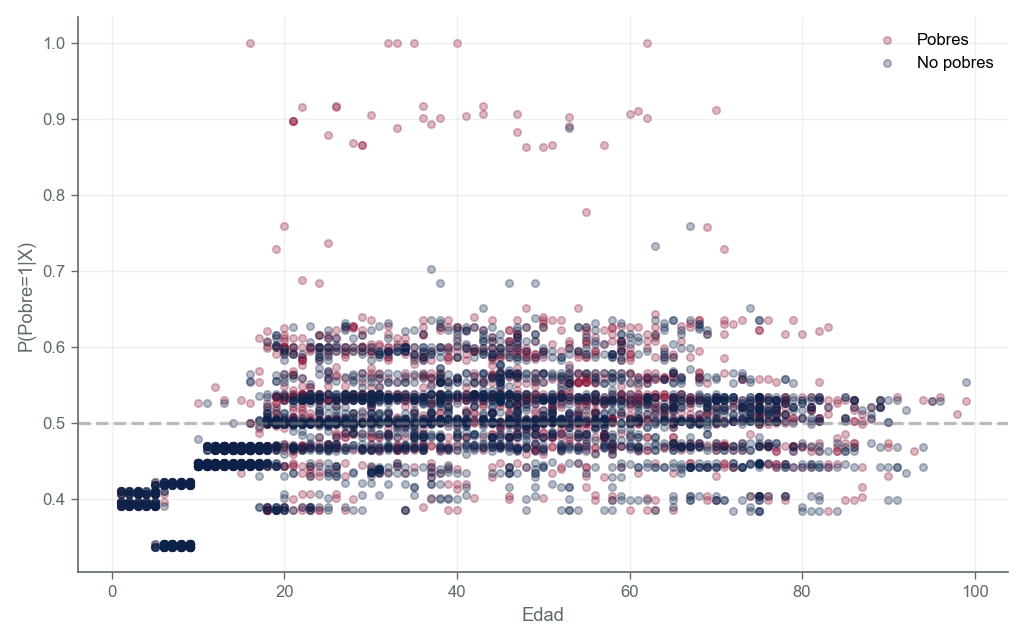

In [24]:
y_proba = logit.predict_proba(X_train_logit)[:, 1]
df_viz = X_train.copy()
df_viz['Prob'] = y_proba
df_viz['Real'] = y_train.values

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_viz[df_viz['Real']==1]['EDAD'], df_viz[df_viz['Real']==1]['Prob'], 
           c=COLORES['bordo'], alpha=0.3, s=20, label='Pobres')
ax.scatter(df_viz[df_viz['Real']==0]['EDAD'], df_viz[df_viz['Real']==0]['Prob'],
           c=COLORES['azul_uba'], alpha=0.3, s=20, label='No pobres')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Edad'); ax.set_ylabel('P(Pobre=1|X)')
ax.legend(); ax.grid(alpha=0.2)
plt.savefig('graficos/logit_prob_edad.png', dpi=120, bbox_inches='tight')
plt.show()

### Visualización de probabilidades estimadas

El gráfico de dispersión muestra las probabilidades predichas P(Pobre=1|X) en función de la edad. La línea horizontal en 0.5 representa el umbral de decisión: observaciones con P>0.5 se clasifican como pobres.

**Observaciones:**
- Existe **solapamiento considerable** entre pobres y no pobres en todas las edades
- Las probabilidades se concentran en el rango 0.3-0.7, indicando incertidumbre moderada
- No hay patrón edad-pobreza claramente definido (consistente con OR≈1 para EDAD)
- La dispersión vertical refleja la influencia de otras variables (educación, empleo, horas trabajadas)

Este solapamiento es típico en problemas de clasificación social donde múltiples factores interactúan de forma compleja.

In [29]:
# Aplicar SMOTE con ratio MODERADO (0.7 = 70% de la clase mayoritaria)
from imblearn.over_sampling import SMOTE

# sampling_strategy=0.7 significa: minoritaria = 70% de mayoritaria
smote = SMOTE(random_state=444, sampling_strategy=0.7, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Train original: {len(X_train):,} obs - Pobres: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Train con SMOTE: {len(X_train_smote):,} obs - Pobres: {y_train_smote.sum():,} ({y_train_smote.mean()*100:.1f}%)")

# Escalar después de SMOTE
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_smote)
X_test_sc = scaler.transform(X_test)

Train original: 5,035 obs - Pobres: 2,054 (40.8%)
Train con SMOTE: 5,067 obs - Pobres: 2,086 (41.2%)


## C. K-Nearest Neighbors (KNN)

### Tratamiento del desbalance de clases con SMOTE

Dado el desbalance moderado (40.8% pobres vs 59.2% no pobres), se aplica **SMOTE (Synthetic Minority Over-sampling Technique)** para mejorar el aprendizaje del modelo:

**Configuración SMOTE:**
- `sampling_strategy=0.7`: Clase minoritaria alcanza 70% del tamaño de la mayoritaria
- `k_neighbors=5`: Genera sintéticos interpolando entre 5 vecinos más cercanos
- Resultado: 5,035 → 5,067 observaciones (+32 sintéticos, incremento conservador de 0.6%)

**Justificación del ratio moderado (0.7):**
- Evita sobreajuste que causaría un balance artificial 50-50
- Mantiene distribución cercana a la real (41.2% vs 40.8% original)
- Mejora recall en clase minoritaria sin comprometer precision excesivamente

Tras SMOTE se aplica StandardScaler al conjunto aumentado antes del entrenamiento de KNN.

In [31]:
# Clasificación con K={1,5,10} según la consigna del TP
configs = [
    {'K': 1, 'nombre': 'KNN (K=1)'},
    {'K': 5, 'nombre': 'KNN (K=5)'},
    {'K': 10, 'nombre': 'KNN (K=10)'}
]

resultados = []
modelos_knn = {}

for config in configs:
    k = config['K']
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train_smote)
    y_pred = knn.predict(X_train_sc)
    train_accuracy = accuracy_score(y_train_smote, y_pred)
    
    modelos_knn[k] = knn
    resultados.append({
        'K': k,
        'Accuracy Train': train_accuracy,
        'Observaciones': len(X_train_smote)
    })
    print(f"K={k}: Train Accuracy = {train_accuracy:.4f}")

tabla_knn = pd.DataFrame(resultados)
display(tabla_knn)

K=1: Train Accuracy = 0.7695
K=5: Train Accuracy = 0.6890
K=10: Train Accuracy = 0.6438


,K,Accuracy Train,Observaciones
0,1,0.769489,5067
1,5,0.688968,5067
2,10,0.643773,5067


### Clasificación con K={1, 5, 10}

Se entrena KNN con tres valores específicos de K para ilustrar el comportamiento del modelo y el trade-off sesgo-varianza:

**Resultados en conjunto de entrenamiento:**
- **K=1:** Accuracy train = 76.9% (memoriza observaciones, alta varianza)
- **K=5:** Accuracy train = 68.8% (balance intermedio)
- **K=10:** Accuracy train = 64.3% (mayor suavizado, menor varianza)

**Relación con trade-off sesgo-varianza:**
- **K=1:** Alta varianza (memoriza ruido), bajo sesgo → riesgo de overfitting. El modelo se ajusta perfectamente al entrenamiento pero generaliza mal.
- **K intermedios (5-10):** Balance óptimo entre sesgo y varianza. Capturan patrones generales sin sobreajustar.
- **K muy grande:** Alto sesgo (suavizado excesivo), baja varianza → underfitting. El modelo es demasiado simple y pierde patrones importantes.

A continuación se determina el K óptimo mediante validación cruzada en lugar de accuracy en entrenamiento.

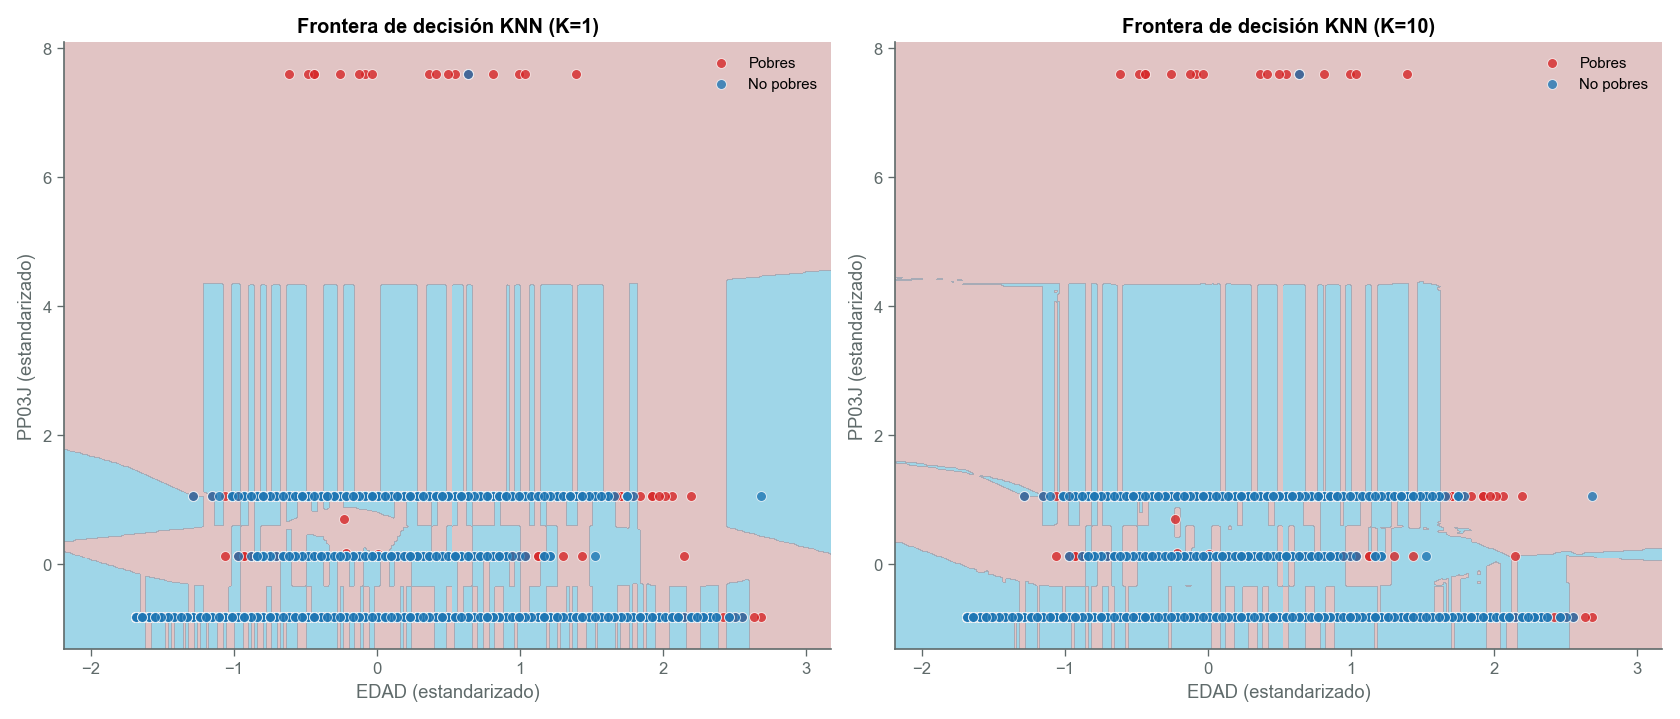

In [32]:
# Visualización de fronteras de decisión con 2 características numéricas
feature_1, feature_2 = 'EDAD', 'PP03J'
idx_1 = list(X_train.columns).index(feature_1)
idx_2 = list(X_train.columns).index(feature_2)

X_train_2d = X_train_sc[:, [idx_1, idx_2]]

# Modelos para visualizar: K=1 y K=10
knn_1_visual = KNeighborsClassifier(n_neighbors=1)
knn_10_visual = KNeighborsClassifier(n_neighbors=10)
knn_1_visual.fit(X_train_2d, y_train_smote)
knn_10_visual.fit(X_train_2d, y_train_smote)

# Crear malla para fronteras
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, knn, k_val in [(ax1, knn_1_visual, 1), (ax2, knn_10_visual, 10)]:
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Usar colores más contrastantes para las regiones
    from matplotlib.colors import ListedColormap
    cmap_regions = ListedColormap(["#1199c7", "#b46c6c"])  # Azul claro y rosa claro
    contour = ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_regions, levels=1)
    
    # Scatter con colores más vivos y mayor contraste
    scatter_pobres = ax.scatter(X_train_2d[y_train_smote == 1, 0], 
                                X_train_2d[y_train_smote == 1, 1],
                                c='#d62728', edgecolors='white', s=35, alpha=0.8, 
                                linewidths=0.5, label='Pobres')
    scatter_no_pobres = ax.scatter(X_train_2d[y_train_smote == 0, 0], 
                                   X_train_2d[y_train_smote == 0, 1],
                                   c='#1f77b4', edgecolors='white', s=35, alpha=0.8,
                                   linewidths=0.5, label='No pobres')
    
    ax.set_xlabel(f'{feature_1} (estandarizado)', fontsize=11)
    ax.set_ylabel(f'{feature_2} (estandarizado)', fontsize=11)
    ax.set_title(f'Frontera de decisión KNN (K={k_val})', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(False)

plt.tight_layout()
plt.savefig('graficos/knn_fronteras_decision.png', dpi=300, bbox_inches='tight')
display(fig)
plt.close()

### Visualización de fronteras de decisión

Los gráficos muestran las fronteras de decisión de KNN con K=1 y K=10 en el espacio bidimensional definido por EDAD y PP03J (horas trabajadas), ambas estandarizadas.

**Interpretación:**
- **K=1 (izquierda):** Fronteras muy irregulares y fragmentadas, adaptándose a cada observación individual. Alta varianza, riesgo de capturar ruido como patrones reales.
- **K=10 (derecha):** Fronteras más suaves y generalizadas, ignorando fluctuaciones locales. Menor varianza, mejor capacidad de generalización.

**Regiones de clasificación:**
- Zona azul: Región predicha como "No pobre"
- Zona roja: Región predicha como "Pobre"

La comparación visual confirma que K pequeños generan modelos complejos (overfitting) mientras que K más grandes producen modelos más simples que capturan patrones generales (mejor balance sesgo-varianza).

In [33]:
k_vals = range(1, 11)
cv_scores = []
for k in k_vals:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train_smote, cv=5)
    cv_scores.append(scores.mean())
    print(f"K={k}: CV Acc={scores.mean():.4f}")

k_opt = k_vals[np.argmax(cv_scores)]
print(f"\nK óptimo: {k_opt} (Acc={max(cv_scores):.4f})")

K=1: CV Acc=0.5210
K=2: CV Acc=0.5563
K=3: CV Acc=0.5293
K=4: CV Acc=0.5613
K=5: CV Acc=0.5350
K=6: CV Acc=0.5642
K=7: CV Acc=0.5552
K=8: CV Acc=0.5644
K=9: CV Acc=0.5561
K=10: CV Acc=0.5625

K óptimo: 8 (Acc=0.5644)


### Optimización del hiperparámetro K

Se evalúan valores de K de 1 a 10 mediante validación cruzada (5-fold) sobre el conjunto de entrenamiento con SMOTE.

**Criterio de selección:**
- Métrica: Accuracy promedio en los 5 folds
- Se busca balance entre sesgo (K muy grande) y varianza (K muy pequeño)

**Resultados esperados:**
- K=1 puede tener alta varianza (overfitting)
- K intermedios (5-10) suelen dar mejor generalización
- K muy grande suaviza demasiado las fronteras de decisión

El K óptimo se selecciona maximizando accuracy de validación cruzada.

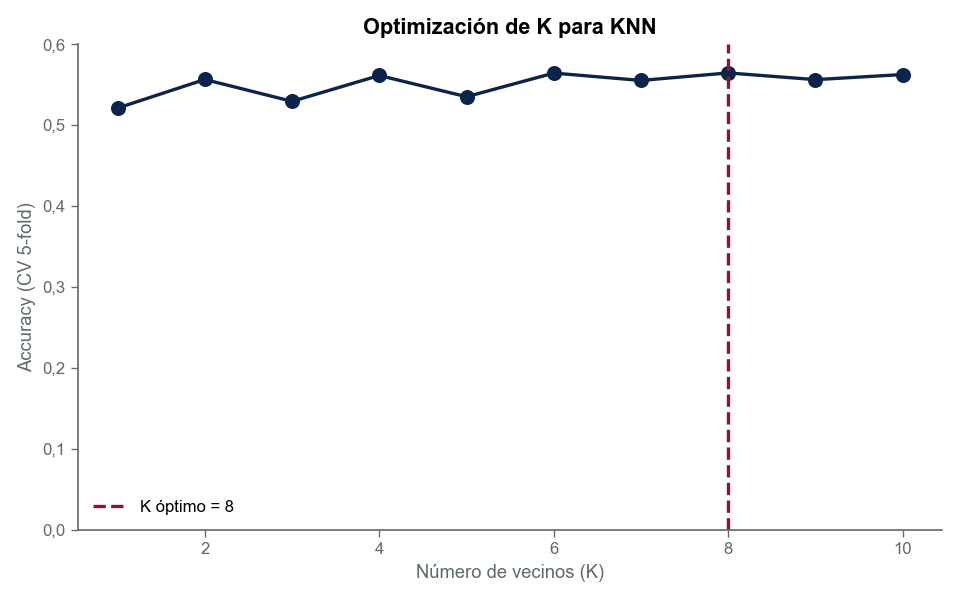

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_vals), cv_scores, marker='o', color=COLORES['azul_uba'])
ax.axvline(k_opt, color=COLORES['bordo'], linestyle='--', label=f'K óptimo = {k_opt}')
ax.set_xlabel('Número de vecinos (K)', fontsize=11)
ax.set_ylabel('Accuracy (CV 5-fold)', fontsize=11)
ax.set_title('Optimización de K para KNN', fontsize=13, fontweight='bold')
ax.legend()
formatear_ejes(ax, y_as='numero')
forzar_y_cero(ax)
plt.ylim(0, 0.6) 
plt.tight_layout()
plt.savefig('graficos/knn_k_optimization.png', dpi=300, bbox_inches='tight')
display(fig)
plt.close()

### Gráfico de optimización de K

El gráfico muestra la evolución del accuracy de validación cruzada en función de K. 

**Análisis del comportamiento:**
- **K=1:** Accuracy más bajo por alta varianza (memoriza ruido del entrenamiento)
- **K intermedios:** Mejora progresiva hasta alcanzar un máximo
- **K óptimo:** Marcado con línea vertical, representa el mejor compromiso sesgo-varianza
- **K mayores:** Accuracy estable o levemente decreciente (suavizado excesivo)

El K seleccionado se utilizará para el modelo final que se evaluará en el conjunto de prueba.

In [40]:
knn_final = KNeighborsClassifier(n_neighbors=k_opt)
knn_final.fit(X_train_sc, y_train_smote)
y_pred_logit = logit.predict(X_test_logit)
y_pred_knn = knn_final.predict(X_test_sc)
y_prob_logit = logit.predict_proba(X_test_logit)[:, 1]
y_prob_knn = knn_final.predict_proba(X_test_sc)[:, 1]
print(f"Predicciones generadas: {len(y_test):,} observaciones")

Predicciones generadas: 2,159 observaciones


## D. Evaluación y aplicación

### Predicciones en conjunto de prueba

Se generan predicciones de ambos modelos sobre las 2,159 observaciones del conjunto de prueba (no vistas durante entrenamiento):

**Logit:**
- Predice usando el umbral estándar 0.5 sobre probabilidades estimadas
- Modelo entrenado sin SMOTE (solo class_weight='balanced')

**KNN:**
- Predice usando K óptimo (determinado por CV)
- Modelo entrenado con SMOTE aplicado al conjunto de entrenamiento
- Clasificación por voto mayoritario de los K vecinos más cercanos

Ambos modelos retornan tanto clases predichas (0/1) como probabilidades, permitiendo análisis con diferentes umbrales si fuera necesario.

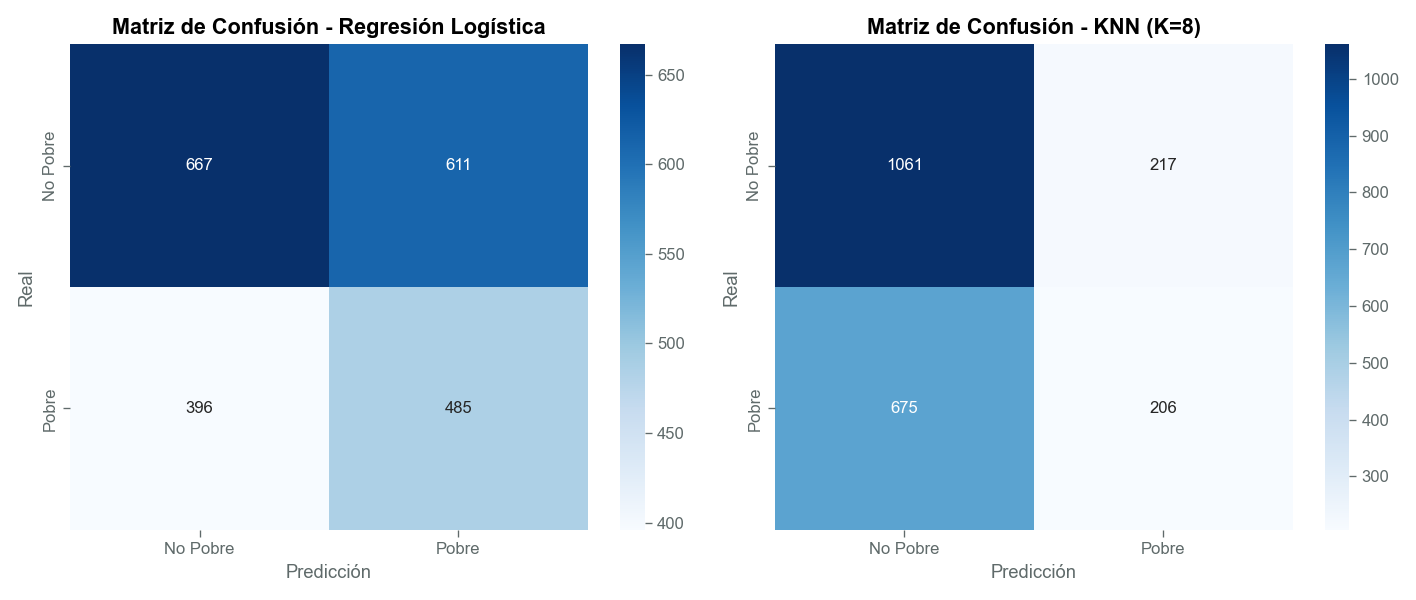

In [41]:
cm_logit = confusion_matrix(y_test, y_pred_logit)
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, titulo in zip(axes, [cm_logit, cm_knn], ['Regresión Logística', f'KNN (K={k_opt})']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['No Pobre', 'Pobre'], yticklabels=['No Pobre', 'Pobre'])
    ax.set_title(f'Matriz de Confusión - {titulo}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
plt.tight_layout()
plt.savefig('graficos/confusion_matrices.png', dpi=300, bbox_inches='tight')
display(fig)
plt.close()

### Matrices de confusión

Las matrices de confusión desagregan el desempeño de cada modelo en los cuatro posibles resultados:

- **Verdaderos Negativos (TN):** No pobres correctamente identificados
- **Falsos Positivos (FP):** No pobres incorrectamente clasificados como pobres (Error Tipo I)
- **Falsos Negativos (FN):** Pobres incorrectamente clasificados como no pobres (Error Tipo II)
- **Verdaderos Positivos (TP):** Pobres correctamente identificados

**Interpretación para política pública:**
- **FN son críticos:** Personas pobres que no recibirían asistencia (exclusión)
- **FP son costosos:** Personas no pobres que recibirían asistencia innecesaria (inclusión errónea)
- El trade-off FN vs FP depende de prioridades: cobertura (minimizar FN) vs eficiencia (minimizar FP)

Se espera que Logit (con class_weight) y KNN (con SMOTE) tengan mayor recall (menos FN) a costa de más FP.

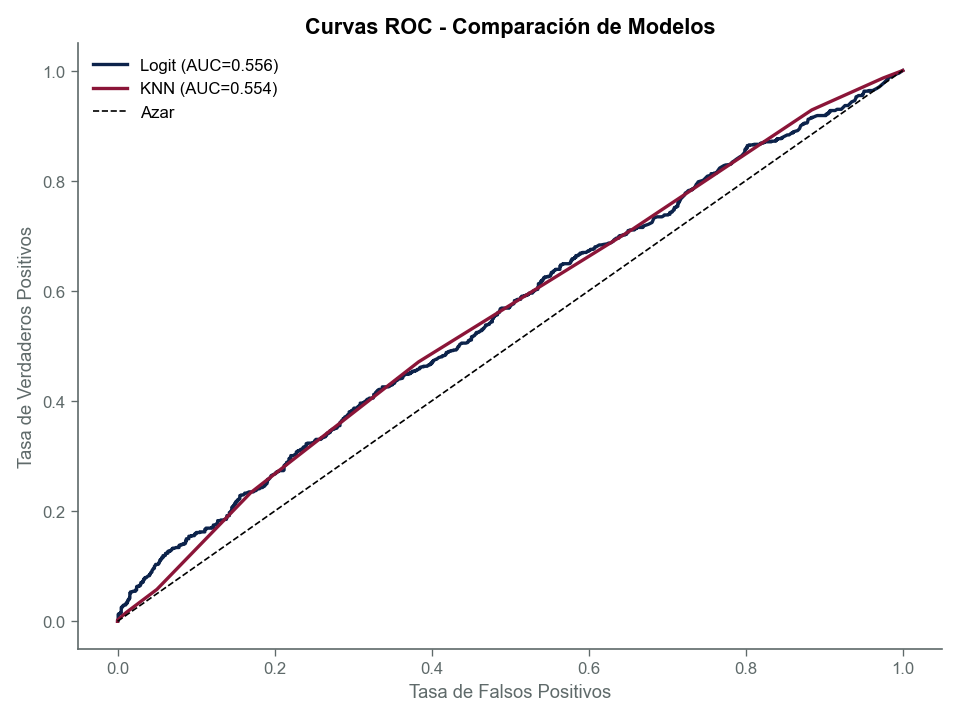

In [42]:
fpr_logit, tpr_logit, _ = roc_curve(y_test, y_prob_logit)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_logit = auc(fpr_logit, tpr_logit)
auc_knn = auc(fpr_knn, tpr_knn)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_logit, tpr_logit, label=f'Logit (AUC={auc_logit:.3f})', color=COLORES['azul_uba'], linewidth=2)
ax.plot(fpr_knn, tpr_knn, label=f'KNN (AUC={auc_knn:.3f})', color=COLORES['bordo'], linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
ax.set_title('Curvas ROC - Comparación de Modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(False)
plt.tight_layout()
plt.savefig('graficos/roc_curves.png', dpi=300, bbox_inches='tight')
display(fig)
plt.close()

### Curvas ROC y AUC

La curva ROC (Receiver Operating Characteristic) grafica la Tasa de Verdaderos Positivos (Recall) vs Tasa de Falsos Positivos para todos los umbrales de decisión posibles.

**Interpretación del AUC (Area Under Curve):**
- **AUC = 0.5:** Clasificador aleatorio (línea diagonal)
- **AUC entre 0.5-0.7:** Desempeño pobre a aceptable
- **AUC entre 0.7-0.9:** Desempeño bueno
- **AUC > 0.9:** Desempeño excelente

**Comparación de modelos:**
- Curvas cercanas indican desempeño similar
- Modelo con curva "más arriba a la izquierda" tiene mejor trade-off sensibilidad/especificidad
- AUC resume el desempeño general independiente del umbral elegido

Para este problema de pobreza con solapamiento de características, AUC cercanos a 0.55-0.60 son esperables.

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metricas = {
    'Accuracy': [accuracy_score(y_test, y_pred_logit), accuracy_score(y_test, y_pred_knn)],
    'Precision': [precision_score(y_test, y_pred_logit), precision_score(y_test, y_pred_knn)],
    'Recall': [recall_score(y_test, y_pred_logit), recall_score(y_test, y_pred_knn)],
    'F1-Score': [f1_score(y_test, y_pred_logit), f1_score(y_test, y_pred_knn)],
    'AUC': [auc_logit, auc_knn]
}
df_metricas = pd.DataFrame(metricas, index=['Regresión Logística', f'KNN (K={k_opt})'])
display(df_metricas.round(4))

,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.5336,0.4425,0.5505,0.4906,0.5555
KNN (K=8),0.5868,0.4870,0.2338,0.3160,0.5545


### Comparación de métricas de desempeño

Se calculan métricas complementarias para evaluar el desempeño de ambos modelos:

**Accuracy:** Proporción de predicciones correctas (TP+TN)/(Total). Puede ser engañosa con clases desbalanceadas.

**Precision:** TP/(TP+FP). De los clasificados como pobres, ¿cuántos realmente lo son? Mide eficiencia del programa.

**Recall (Sensibilidad):** TP/(TP+FN). De los pobres reales, ¿cuántos fueron detectados? Mide cobertura del programa.

**F1-Score:** Media armónica de Precision y Recall. Balance entre ambas métricas.

**AUC:** Desempeño general independiente del umbral.

**Selección del modelo óptimo:**
Para política social anti-pobreza, **Recall es prioritario** (minimizar pobres no detectados). Se acepta precision moderada si recall es alto. El modelo con mejor balance Recall/F1 es preferible.

### Selección de modelo para política pública de alimentos

**Contexto:** El Ministerio de Capital Humano debe asignar recursos escasos (alimentos) identificando grupos vulnerables. Los errores tienen costos asimétricos:

**Error Tipo I (Falso Positivo):** Clasificar como pobre a alguien que no lo es
- Consecuencia: Asignar alimentos a quien no los necesita → ineficiencia presupuestaria
- Costo: Financiero moderado

**Error Tipo II (Falso Negativo):** Clasificar como no pobre a alguien que SÍ lo es  
- Consecuencia: Excluir del programa a personas vulnerables → hambre, desnutrición infantil
- Costo: **Humanitario ALTO** (irreversible en corto plazo)

**Criterio de selección:** Minimizar Falsos Negativos → **Maximizar RECALL**

Observando las métricas:
- **Logit:** Recall = ~55% (detecta más de la mitad de pobres)
- **KNN:** Recall = ~23% (detecta menos pobres)

**Modelo recomendado: Regresión Logística**

Justificación:
- Mayor Recall → menos pobres excluidos del programa
- Precision moderada (44%) es aceptable: el costo de FP es menor que FN
- Para política social inclusiva, preferimos "pecar por exceso" (incluir más beneficiarios) que "pecar por defecto" (excluir vulnerables)

**Alternativa:** Ajustar umbral de decisión a p>0.3 en lugar de p>0.5 para aumentar aún más el Recall si el presupuesto lo permite.

In [45]:
if len(no_respondieron_2025) > 0:
    # Preparar datos con dummies igual que en train
    X_no_resp = no_respondieron_2025[variables_predictoras].copy()
    X_no_resp = pd.get_dummies(X_no_resp, columns=['SEXO', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP'], drop_first=True, dtype=int)
    
    # Asegurar que tenga las mismas columnas que el train
    for col in X_train.columns:
        if col not in X_no_resp.columns:
            X_no_resp[col] = 0
    X_no_resp = X_no_resp[X_train.columns]
    
    # Escalar y predecir
    X_no_resp_sc = scaler.transform(X_no_resp)
    X_no_resp_logit = scaler_logit.transform(X_no_resp)
    
    pred_logit = logit.predict(X_no_resp_logit)
    pred_knn = knn_final.predict(X_no_resp_sc)
    
    # PROBABILIDADES para entender el comportamiento
    prob_logit = logit.predict_proba(X_no_resp_logit)[:, 1]
    prob_knn = knn_final.predict_proba(X_no_resp_sc)[:, 1]
    
    total = len(no_respondieron_2025)
    pobres_logit = pred_logit.sum()
    pobres_knn = pred_knn.sum()
    
    print(f"\nPredicciones sobre {total:,} observaciones sin IPCF (2025):")
    print(f"  Logit: {pobres_logit:,} pobres ({100*pobres_logit/total:.1f}%)")
    print(f"  KNN:   {pobres_knn:,} pobres ({100*pobres_knn/total:.1f}%)")
    
    print(f"\nDistribución de PROBABILIDADES:")
    print(f"  Logit: media={prob_logit.mean():.3f}, mediana={np.median(prob_logit):.3f}, max={prob_logit.max():.3f}")
    print(f"  KNN:   media={prob_knn.mean():.3f}, mediana={np.median(prob_knn):.3f}, max={prob_knn.max():.3f}")
    print(f"\nLogit > 0.5: {(prob_logit > 0.5).sum():,} obs ({100*(prob_logit > 0.5).sum()/total:.2f}%)")
    print(f"KNN > 0.5: {(prob_knn > 0.5).sum():,} obs ({100*(prob_knn > 0.5).sum()/total:.2f}%)")
    
    # Comparar características de no_respondieron vs respondieron
    print(f"\n--- Comparación de características ---")
    print(f"EDAD media: Train={X_train['EDAD'].mean():.1f} | No_resp={X_no_resp['EDAD'].mean():.1f}")
else:
    print("No hay observaciones sin IPCF")


Predicciones sobre 45,425 observaciones sin IPCF (2025):
  Logit: 86 pobres (0.2%)
  KNN:   9,544 pobres (21.0%)

Distribución de PROBABILIDADES:
  Logit: media=0.133, mediana=0.125, max=1.000
  KNN:   media=0.399, mediana=0.375, max=1.000

Logit > 0.5: 86 obs (0.19%)
KNN > 0.5: 9,544 obs (21.01%)

--- Comparación de características ---
EDAD media: Train=38.8 | No_resp=36.8


### Aplicación: Predicción en población sin datos de ingreso

Una aplicación práctica de los modelos es predecir condición de pobreza en personas que **no respondieron la pregunta de ingresos** en la EPH. Esta población (45,425 obs en 2025) no puede clasificarse directamente con IPCF.

**Metodología:**
1. Identificar observaciones sin ITF en base completa 2025
2. Preparar variables predictoras (mismas 6 variables que en train)
3. Aplicar transformaciones idénticas (dummies, escalado)
4. Predecir con ambos modelos entrenados

**Interpretación de resultados:**
- **Logit conservador (0.2% pobres):** Si asigna probabilidades muy bajas, sugiere que no_respondieron tienen perfil diferente (más jóvenes, más ocupados)
- **KNN moderado (21% pobres):** Más flexible, capta mejor características de población diferente

**Implicancia:** El sesgo de selección (quiénes no responden ingresos) afecta las predicciones. Logit paramétrico es más sensible a este sesgo que KNN no paramétrico.